# Day 18 – Classification and MNIST

**Goal:** Learn how a classification model predicts classes, evaluate accuracy, and understand why scaling and cross-validation matter.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the MNIST Dataset

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target']
y = y.astype(np.int64)

print('Feature shape:', X.shape)
print('Target shape :', y.shape)
print('First label:', y[0])

Feature shape: (70000, 784)
Target shape : (70000,)
First label: 5


## 3. Visualize One Digit

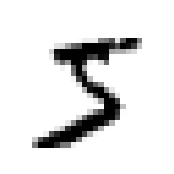

In [3]:
some_digit = X[0].reshape(28, 28)
plt.figure(figsize=(2, 2))
plt.imshow(some_digit, cmap='binary')
plt.axis('off')
plt.show()

## 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (56000, 784)
Test size : (14000, 784)


## 5. Scale Features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling completed.')

Feature scaling completed.


## 6. Train an SGD Classifier

In [6]:
sgd_clf = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-3, random_state=42)
sgd_clf.fit(X_train_scaled, y_train)

print('Model training completed!')

Model training completed!


c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


## 7. Make Predictions

In [7]:
y_pred = sgd_clf.predict(X_test_scaled)
print('Predictions completed.')

Predictions completed.


## 8. Evaluate the Model

In [8]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', round(acc, 4))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9128

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1381
           1       0.96      0.96      0.96      1575
           2       0.93      0.89      0.91      1398
           3       0.91      0.88      0.89      1428
           4       0.94      0.90      0.92      1365
           5       0.88      0.84      0.86      1263
           6       0.93      0.95      0.94      1375
           7       0.94      0.93      0.94      1459
           8       0.81      0.91      0.86      1365
           9       0.88      0.89      0.89      1391

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



## 9. Cross-Validation

In [9]:
cv_scores = cross_val_score(
    SGDClassifier(loss='log_loss', max_iter=100, tol=1e-3, random_state=42),
    X_train_scaled,
    y_train,
    cv=3,
    scoring='accuracy'
)

print('Cross-validation scores:', np.round(cv_scores, 4))
print('Mean CV accuracy:', round(cv_scores.mean(), 4))

c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Cross-validation scores: [0.9104 0.9111 0.9144]
Mean CV accuracy: 0.912


c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


# Final Summary
In this notebook you learned how a simple classifier can be trained on MNIST data, why scaling matters, and how accuracy and cross-validation help evaluate performance.